# **Libraries**

In [1]:
%run ../../../setup_workspace.py # ../ means level up 

# **Data**

In [2]:
poni_saxs = r'/Users/akmalumarov/Desktop/Cu NPs/IHSC 1872/SAXS_1p4m_12keV.poni'
ai_saxs = pyFAI.load(poni_saxs)

poni_waxs = r'/Users/akmalumarov/Desktop/Cu NPs/IHSC 1872/WAXS_1p4m_12keV.poni'
ai_waxs = pyFAI.load(poni_waxs)

mask_saxs = r'/Users/akmalumarov/Desktop/Cu NPs/IHSC 1872/MASK_SAXS_1p4m_12keV_2.edf'
img_mask_saxs = fabio.open(mask_saxs).data

mask_waxs = r'/Users/akmalumarov/Desktop/Cu NPs/IHSC 1872/MASK2_WAXS_1p4m_12keV.edf'
img_mask_waxs = fabio.open(mask_waxs).data

In [19]:
path = r'/Users/akmalumarov/Desktop/Cu NPs/IHSC 1872/CuPE_3perc_1_4m_beforetrans/CuPE_3perc_1_4m_beforetrans_Ht_190C_10Kpm'
Cu_3_heat = BM26_experiment(path)

path = r'/Users/akmalumarov/Desktop/Cu NPs/IHSC 1872/CuPE_3perc_1_4m_beforetrans/CuPE_3perc_1_4m_beforetrans_Isoth_190C'
Cu_3_iso = BM26_experiment(path)

path = r'/Users/akmalumarov/Desktop/Cu NPs/IHSC 1872/CuPE_0_5perc_1_4m_beforetrans/CuPE_0_5perc_1_4m_beforetrans_Ht_190C_10Kpm'
Cu_05_heat = BM26_experiment(path)

path = r'/Users/akmalumarov/Desktop/Cu NPs/IHSC 1872/CuPE_0_5perc_1_4m_beforetrans/CuPE_0_5perc_1_4m_beforetrans_Isoth_190C_30min'
Cu_05_iso = BM26_experiment(path)

# **Functions**

In [6]:
def quick_edit(x, y):
    from ipywidgets import interact, FloatSlider, IntSlider, VBox
    import plotly.graph_objects as go
    from IPython.display import display
    
    y_ed = y.copy()
    
    # Используем CSS для установки размера
    fig = go.FigureWidget()
    fig.add_scatter(x=x, y=y_ed, mode='lines+markers', marker=dict(size=8))
    
    # Устанавливаем размер через layout
    fig.layout.update(
        width=760,
        height=760,
        autosize=False
    )
    
    # Слайдеры
    idx_slider = IntSlider(min=0, max=len(x)-1, step=1, value=0, description='Index:')
    y_slider = FloatSlider(min=float(min(y) / 1.5), max=float(max(y) * 1.5), 
                          value=float(y[0]), step=(max(y)-min(y))/5000,
                          description='Y:', readout_format='.4f')
    
    def update(idx, val):
        y_ed[idx] = val
        fig.data[0].y = y_ed
    
    def on_click(trace, points, selector):
        if points.point_inds:
            idx = points.point_inds[0]
            idx_slider.value = idx
            y_slider.value = y_ed[idx]
    
    fig.data[0].on_click(on_click)
    
    display(fig)
    interact(update, idx=idx_slider, val=y_slider)
    
    return y_ed

def remove_peaks(y, min_width=10):
    peaks = find_peaks(y)[0]
    if len(peaks) == 0:
        return y
    
    widths = peak_widths(y, peaks, rel_height=0.5)[0]
    narrow_peaks = peaks[widths < min_width]
    
    y_clean = y.copy()
    for p in narrow_peaks:
        left = max(0, p - int(widths[peaks == p][0]) * 2)
        right = min(len(y), p + int(widths[peaks == p][0]) * 2)
        y_clean[left:right] = np.linspace(y[left], y[right], right - left)
    
    return y_clean

In [7]:
def Guinier(q, I_0, R_g):
    return I_0 * np.exp(-q ** 2 * R_g ** 2 / 3)

def norm_saxs(q, I_array):
    for i in range(len(I_array)):
        I = I_array[i]
        I /= np.mean(I[(q>4)*(q<5)])
    #return q, I

    

def norm_waxs(q, I_array):
    for i in range(len(I_array)):
        I = I_array[i]
        I /= np.mean(I[(q>20)*(q<20.5)])
    #return q, I

# **Results**

### *Divide*

In [44]:
q, I_heat = Cu_3_heat.integrate1d_SAXS(ai_saxs, 2000, mask = img_mask_saxs)
Time_heat = Cu_3_heat.get_Time_profile()
q, I_iso = Cu_3_iso.integrate1d_SAXS(ai_saxs, 2000, mask = img_mask_saxs)
Time_iso = Cu_3_heat.get_Time_profile()

I_3_heat = []
I_3_iso = []

T_3_heat = Cu_3_heat.get_T_profile()[:83]
Time_3_iso = []

for i in range(83):
    I_3_heat.append(I_heat[i])

for i in range(6):
    I_3_iso.append(I_heat[83 + i])
    Time_3_iso.append(Time_heat[83 + i])

for i in range(60):
    I_3_iso.append(I_iso[i])
    Time_3_iso.append(Time_iso[i])

Time_3_iso = np.array(Time_3_iso)
T_3_heat = np.array(T_3_heat)

Time_3_iso -= min(Time_3_iso)

print(len(I_3_heat), len(T_3_heat))
print(len(I_3_iso), len(Time_3_iso))

Found 89 EDF files in SAXS
83 83
66 66


In [45]:
q, I_heat = Cu_05_heat.integrate1d_SAXS(ai_saxs, 2000, mask = img_mask_saxs)
Time_heat = Cu_05_heat.get_Time_profile()
q, I_iso = Cu_05_iso.integrate1d_SAXS(ai_saxs, 2000, mask = img_mask_saxs)
Time_iso = Cu_05_heat.get_Time_profile()

I_05_heat = []
I_05_iso = []

T_05_heat = Cu_05_heat.get_T_profile()[:83]
Time_05_iso = []

for i in range(83):
    I_05_heat.append(I_heat[i])

for i in range(5):
    I_05_iso.append(I_heat[83 + i])
    Time_05_iso.append(Time_heat[83 + i])

for i in range(66):
    I_05_iso.append(I_iso[i])
    Time_05_iso.append(Time_iso[i])

Time_05_iso = np.array(Time_05_iso)
T_05_heat = np.array(T_05_heat)

Time_05_iso -= min(Time_05_iso)

print(len(I_05_heat), len(T_05_heat))
print(len(I_05_iso), len(Time_05_iso))

Found 88 EDF files in SAXS
83 83
71 71


### *Analysis*

In [52]:
def norm_saxs(q, I_data):
    for i in range(len(I_data)):
        I_data[i] /= np.mean(I_data[i][(q>6)*(q<7)])

In [53]:
norm_saxs(q, I_3_heat)
norm_saxs(q, I_3_iso)
norm_saxs(q, I_05_heat)
norm_saxs(q, I_05_iso)


(0.16, 2)

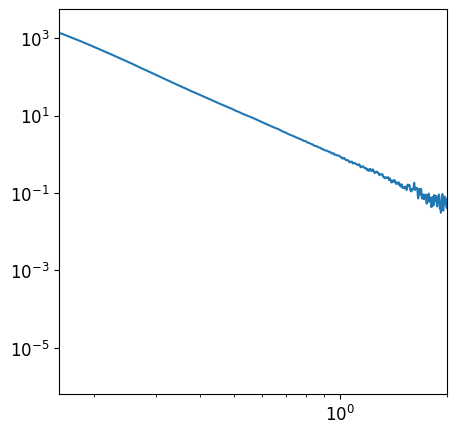

In [256]:
plt.figure(figsize=(5,5))

bkg = I_05_heat[45]
# plt.loglog(q, bkg - 0.995 * bkg)

I = I_05_heat[-1]
plt.loglog(q, I - 0.995 * bkg)

I = I_05_heat[63]
plt.loglog(q, I - 0.995 * bkg)

I = I_05_iso[-1]
plt.loglog(q, I - 0.995 * bkg)

plt.xlim(0.16, 2)

##### **Guinier**

In [277]:
def linear(x, a, b):
    return a * x + b
    
def Rg_from_fit(a):
    return np.sqrt(3 * np.abs(a))

def fit_fraction(q, I, left, right, plot=True):
    X = q**2
    Y = np.log(I)
    mask = (X > left) & (X < right)
    
    p, _ = curve_fit(linear, X[mask], Y[mask])
    Rg = np.sqrt(-3 * p[0])
    K = np.exp(p[1])
    I_model = K * np.exp(-q**2 * Rg**2 / 3)

    if plot == True:
        plt.figure(figsize=(4,4))
        plt.xlim(0, right)
        plt.ylim(-5, max(Y) * 1.5)
        plt.scatter(X, Y, color='black')
        plt.scatter(X[mask], Y[mask])
        lnsp = np.linspace(0, 4, 1000)
        plt.plot(lnsp, linear(lnsp, *p), color='r', linestyle='--')
        print(Rg)
        
    
    return Rg, K, I_model

1.6953260382459174
3.562098302049742
6.308926113657072
11.05892758137556
19.146898386367457


/var/folders/x1/4fkphp0x19n84r906qq41l240000gn/T/ipykernel_18857/1910136263.py:9: RuntimeWarning:

invalid value encountered in log



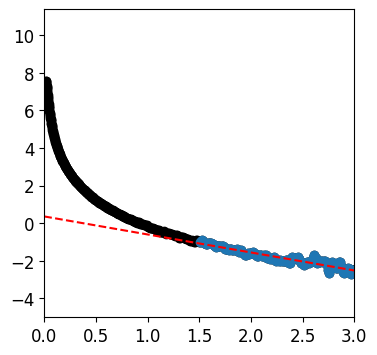

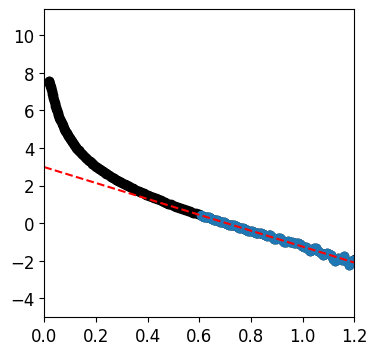

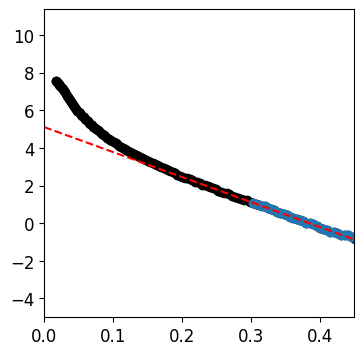

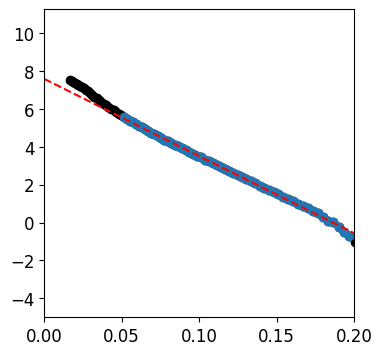

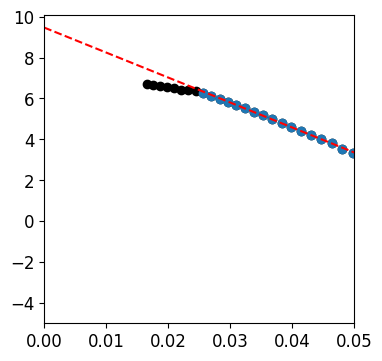

In [278]:
# Использование
I_cur = I_05_iso[-1] - 0.995 * bkg

# Фракция 1
R1, K1, I1 = fit_fraction(q, I_cur, left=1.5, right=3)
I_cur = I_cur - I1  # вычитаем

# Фракция 2
R2, K2, I2 = fit_fraction(q, I_cur, left=0.6, right=1.2)
I_cur = I_cur - I2

# Фракция 3
R3, K3, I3 = fit_fraction(q, I_cur, left=0.3, right=0.45)
I_cur = I_cur - I3

# Фракция 4
R4, K4, I4 = fit_fraction(q, I_cur, left=0.05, right=0.2)
I_cur = I_cur - I4

# Фракция 5
R5, K5, I5 = fit_fraction(q, I_cur, left=0.025, right=0.05)
I_cur = I_cur - I5

fractions = [K1, K2, K3, K4, K5]
Rgs = [R1, R2, R3, R4, R5]

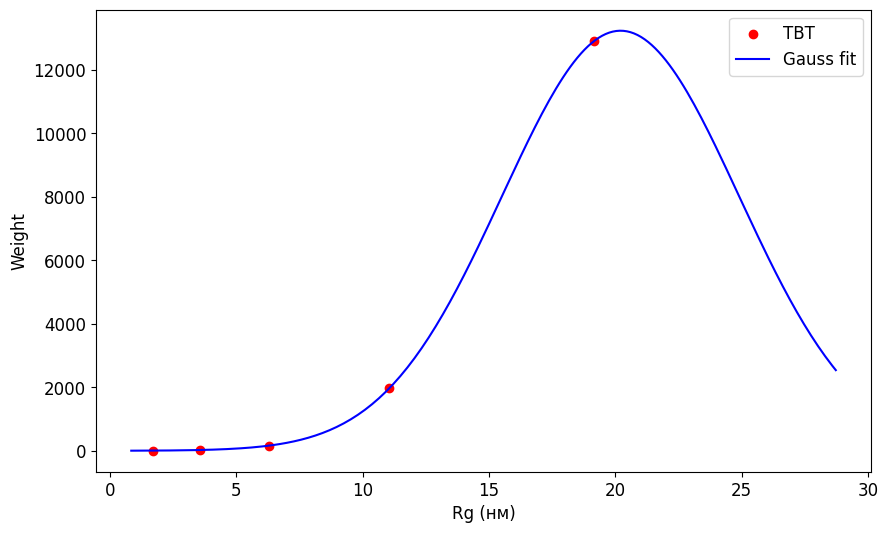

mu = 20.20 нм, sigma = 4.69 нм


In [275]:
# from scipy.optimize import curve_fit

# def gaussian(R, mu, sigma, A):
#     return A * np.exp(-(R - mu)**2 / (2 * sigma**2))

# # Фит
# popt, _ = curve_fit(gaussian, Rgs, fractions, #p0=[Rgs[np.argmax(fractions)], 10, max(fractions)], 
#                     maxfev = 5000)

# # График
# R_cont = np.linspace(min(Rgs)*0.5, max(Rgs)*1.5, 200)

plt.figure()
plt.scatter(Rgs, fractions, color='red', label='TBT')
plt.plot(R_cont, gaussian(R_cont, *popt), 'b-', label='Gauss fit')
plt.xlabel('Rg (нм)')
plt.ylabel('Weight')
plt.legend()
plt.show()

print(f"mu = {popt[0]:.2f} нм, sigma = {popt[1]:.2f} нм")

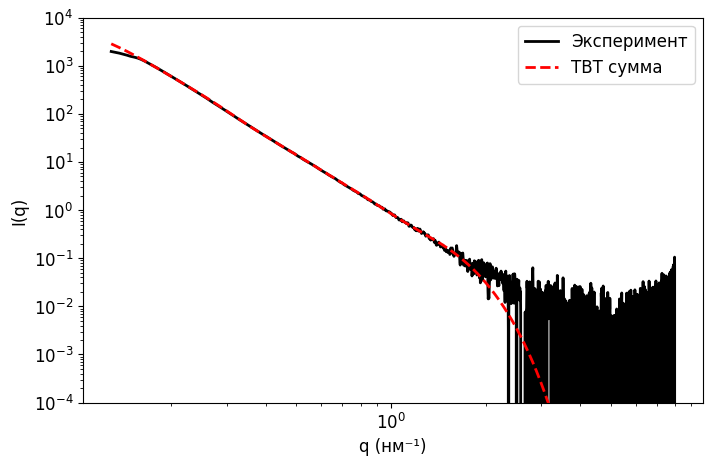

RMS error = nan


/var/folders/x1/4fkphp0x19n84r906qq41l240000gn/T/ipykernel_18857/3128778408.py:24: RuntimeWarning:

invalid value encountered in log



In [276]:
def total_scattering(q, Rgs, fractions):
    """
    Суммарная SAXS интенсивность от всех фракций
    """
    I_total = np.zeros_like(q)
    for Rg, K in zip(Rgs, fractions):
        I_total += K * np.exp(-q**2 * Rg**2 / 3)
    return I_total

# Расчет
I_calc = total_scattering(q, Rgs, fractions)

# Сравнение с оригиналом
plt.figure(figsize=(8,5))
plt.loglog(q, I_orig, 'k-', label='Эксперимент', linewidth=2)
plt.loglog(q, I_calc, 'r--', label='TBT сумма', linewidth=2)
plt.xlabel('q (нм⁻¹)')
plt.ylabel('I(q)')
plt.ylim(1e-4, 1e4)
plt.legend()
plt.show()

# Ошибка
error = np.sqrt(np.mean((np.log(I_orig) - np.log(I_calc))**2))
print(f"RMS error = {error:.3f}")

1.6953260382459174
1.439618811288587


/var/folders/x1/4fkphp0x19n84r906qq41l240000gn/T/ipykernel_18857/3856725880.py:1: RuntimeWarning:

invalid value encountered in log



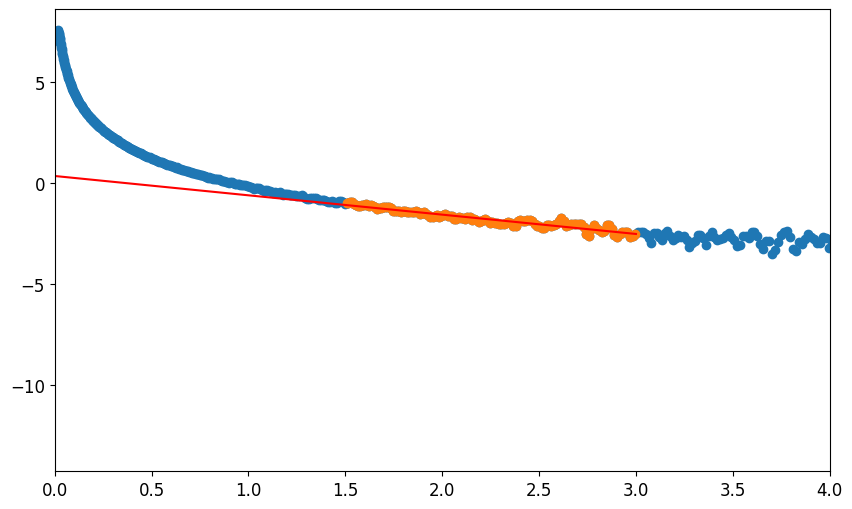

In [164]:
Y = np.log(I_05_iso[-1] - 0.995 * bkg)
X = q ** 2

plt.scatter(X, Y)

plt.xlim(0, 4)

left = 1.5
right = 3
X_fit = X[(X>left)*(X<right)]
Y_fit = Y[(X>left)*(X<right)]
lnsp = np.linspace(0, right, 1000)
plt.scatter(X_fit, Y_fit)

p, cov = curve_fit(linear, X_fit, Y_fit)
plt.plot(lnsp, linear(lnsp, *p), color='r')

Rg_1 = np.sqrt(-3 * p[0])
K_1 = np.e ** p[1]

print(Rg_1)
print(K_1)
# print(0.64 / ( Rg ** 2))
# print(1.64 / ( Rg ** 2))


3.5456496346293687
19.536411959671113


/var/folders/x1/4fkphp0x19n84r906qq41l240000gn/T/ipykernel_18857/3867782662.py:3: RuntimeWarning:

invalid value encountered in log



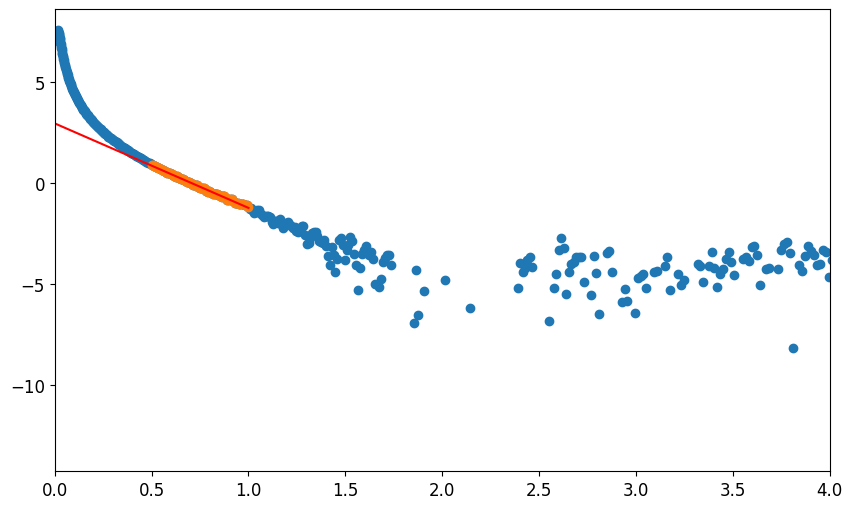

In [165]:
I_ост = I_orig - K_1 * np.exp(-q**2 * Rg_1**2 / 3)

Y_ост = np.log(I_ост)

plt.xlim(0, 4)
plt.scatter(X, Y_ост)

left = .5
right = 1
X_fit = X[(X>left)*(X<right)]
Y_fit = Y_ост[(X>left)*(X<right)]
lnsp = np.linspace(0, right, 1000)
plt.scatter(X_fit, Y_fit)

p, cov = curve_fit(linear, X_fit, Y_fit)
plt.plot(lnsp, linear(lnsp, *p), color='r')

Rg_2 = np.sqrt(-3 * p[0])
K_2 = np.e ** p[1]

print(Rg_2)
print(K_2)
# print(0.64 / ( Rg ** 2))
# print(1.64 / ( Rg ** 2))


1.77948346340367
1.5512993213685013


/var/folders/x1/4fkphp0x19n84r906qq41l240000gn/T/ipykernel_18857/3034653691.py:3: RuntimeWarning:

invalid value encountered in log



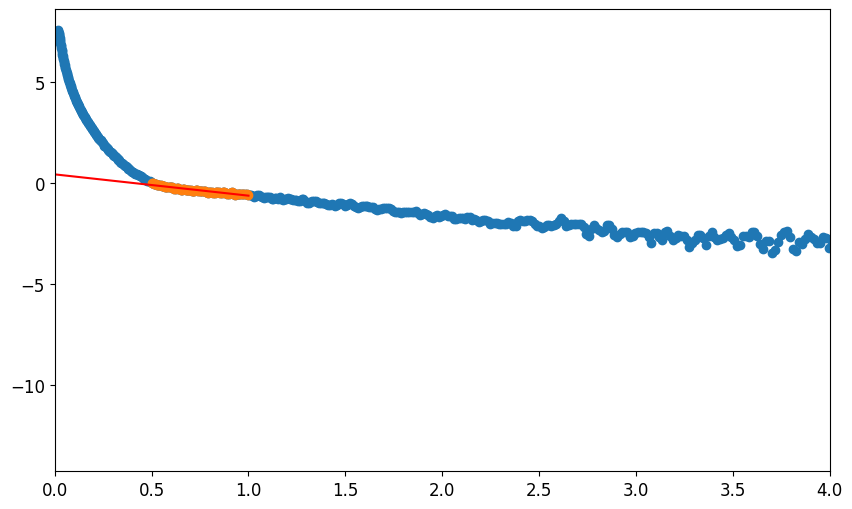

In [166]:
I_ост_2 = I_orig - K_2 * np.exp(-q**2 * Rg_2**2 / 3)

Y_ост = np.log(I_ост)

plt.xlim(0, 4)
plt.scatter(X, Y_ост)

left = .5
right = 1
X_fit = X[(X>left)*(X<right)]
Y_fit = Y_ост[(X>left)*(X<right)]
lnsp = np.linspace(0, right, 1000)
plt.scatter(X_fit, Y_fit)

p, cov = curve_fit(linear, X_fit, Y_fit)
plt.plot(lnsp, linear(lnsp, *p), color='r')

Rg_2 = np.sqrt(-3 * p[0])
K_2 = np.e ** p[1]

print(Rg_2)
print(K_2)
# print(0.64 / ( Rg ** 2))
# print(1.64 / ( Rg ** 2))
